<a href="https://colab.research.google.com/github/Yinhaze/Beginner-Basic-projects/blob/master/NLP_Binary_Text_Classification_Pipeline_with_Scikit_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud datasets

# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import string
import re
import os

from wordcloud import WordCloud

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
)

warnings.filterwarnings("ignore")
%matplotlib inline
print("All imports successful.")

All imports successful.


# Configuration


In [ ]:
CSV_PATH     = "data.csv"
TEXT_COL     = "comment_text"
LABEL_COL    = "toxic"
TEST_SIZE    = 0.20
RANDOM_STATE = 42
MAX_FEATURES = 10_000

HF_DATASET_NAME = "thesofakillers/jigsaw-toxic-comment-classification-challenge"


# Data Loading

In [ ]:
from datasets import load_dataset

print(f"[INFO] Loading dataset from Hugging Face: '{HF_DATASET_NAME}'")
raw_dataset = load_dataset(HF_DATASET_NAME, split='train')

df = raw_dataset.to_pandas()

df = df[[TEXT_COL, LABEL_COL]]
df[LABEL_COL] = df[LABEL_COL].apply(lambda x: 'toxic' if x >= 0.5 else 'not toxic')

df.columns = ["text", "label"]
df.dropna(subset=["text", "label"], inplace=True)
df["text"]  = df["text"].astype(str)
df["label"] = df["label"].astype(str)

print(f"Dataset shape : {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum().to_string()}")

[INFO] Loading dataset from Hugging Face: 'thesofakillers/jigsaw-toxic-comment-classification-challenge'


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

Dataset shape : (159571, 2)

Missing values:
text     0
label    0


In [ ]:
df.head(5)

,text,label
0,Explanation\nWhy the edits made under my usern...,not toxic
1,D'aww! He matches this background colour I'm s...,not toxic
2,"Hey man, I'm really not trying to edit war. It...",not toxic
3,"""\nMore\nI can't make any real suggestions on ...",not toxic
4,"You, sir, are my hero. Any chance you remember...",not toxic


    Class  Count  Percentage
not toxic 144277       90.42
    toxic  15294        9.58


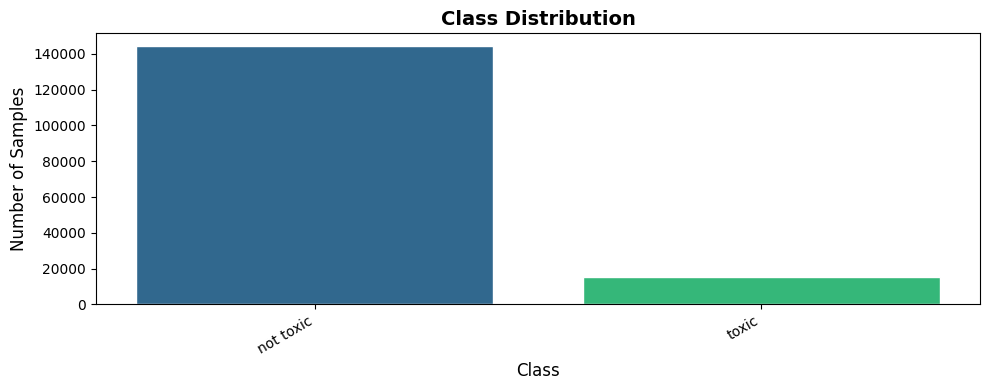

In [ ]:
class_dist = df["label"].value_counts().reset_index()
class_dist.columns = ["Class", "Count"]
class_dist["Percentage"] = (class_dist["Count"] / len(df) * 100).round(2)
print(class_dist.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(class_dist["Class"], class_dist["Count"],
       color=sns.color_palette("viridis", len(class_dist)), edgecolor="white")
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_title("Class Distribution", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

---
# Text Preprocessing

Each text goes through:
1. Lowercase conversion
2. Remove URLs and HTML tags
3. Remove punctuation and digits
4. Tokenisation
5. Stopword removal
6. Lemmatization

In [ ]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words("english"))

def preprocess_text(text: str) -> str:
    """Clean a single text string."""

    text = text.lower()

    text = re.sub(r"http\S+|www\S+|<[^>]+>", " ", text)

    text = text.translate(str.maketrans("", "", string.punctuation + string.digits))

    tokens = text.split()

    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

print("preprocess_text() defined.")

preprocess_text() defined.


In [ ]:
df["clean_text"] = df["text"].apply(preprocess_text)

print("Sample before → after preprocessing:\n")
for _, row in df.head(3).iterrows():
    print(f"  ORIGINAL : {row['text'][:130]}")
    print(f"  CLEANED  : {row['clean_text'][:130]}")
    print()

Sample before → after preprocessing:

  ORIGINAL : Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on so
  CLEANED  : explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please dont r

  ORIGINAL : D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
  CLEANED  : daww match background colour seemingly stuck thanks talk january utc

  ORIGINAL : Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me 
  CLEANED  : hey man really trying edit war guy constantly removing relevant information talking edits instead talk page seems care formatting 




# Word Cloud Visualisation



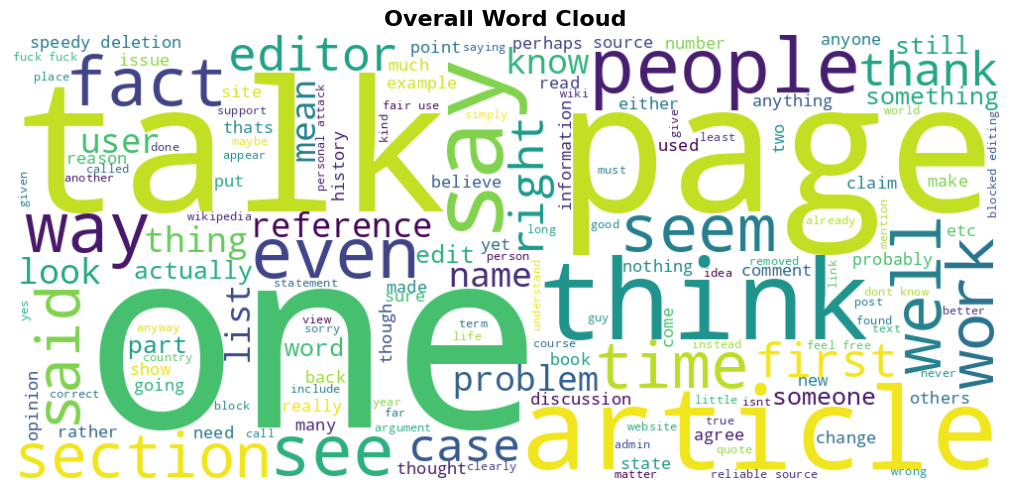

[INFO] Saved → wordcloud_overall.png


In [ ]:
all_text = " ".join(df["clean_text"])
wc_cfg   = dict(width=1000, height=450, background_color="white",
                max_words=150, colormap="viridis")

wc = WordCloud(**wc_cfg).generate(all_text)

plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Overall Word Cloud", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("wordcloud_overall.png", dpi=150, bbox_inches="tight")
plt.show()
print("[INFO] Saved → wordcloud_overall.png")

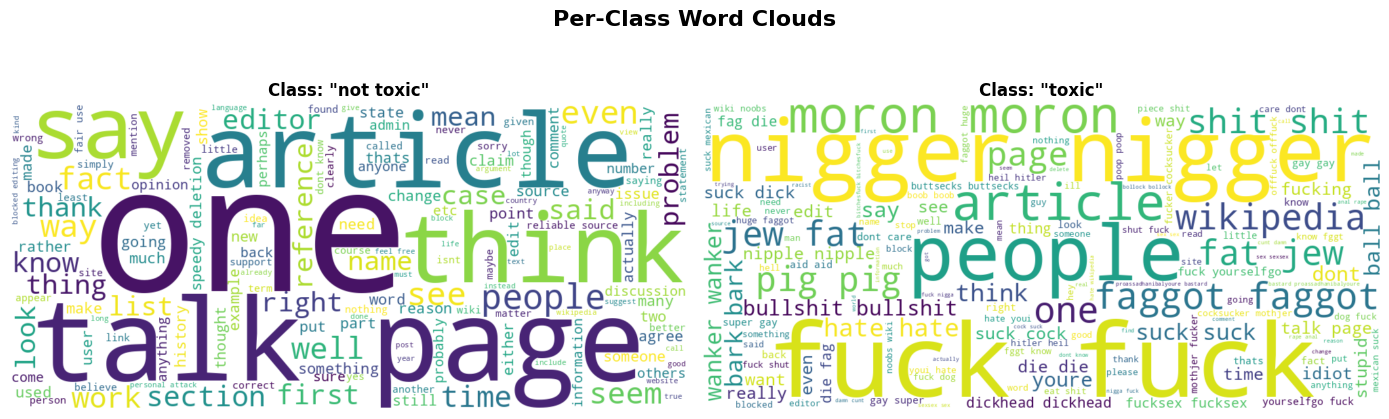

[INFO] Saved → wordclouds_per_class.png


In [ ]:
classes = df["label"].unique()
n_cols  = 2
n_rows  = int(np.ceil(len(classes) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(14, 4.5 * n_rows))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_text = " ".join(df[df["label"] == cls]["clean_text"])
    if cls_text.strip():
        wc = WordCloud(**wc_cfg).generate(cls_text)
        axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].axis("off")
    axes[idx].set_title(f'Class: "{cls}"', fontsize=12, fontweight="bold")

for j in range(len(classes), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Per-Class Word Clouds", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("wordclouds_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("[INFO] Saved → wordclouds_per_class.png")


# Feature Extraction



In [ ]:
TFIDF_PARAMS = dict(max_features=MAX_FEATURES, ngram_range=(1, 2), sublinear_tf=True)
COUNT_PARAMS = dict(max_features=MAX_FEATURES, ngram_range=(1, 2))

print("TF-IDF params  :", TFIDF_PARAMS)
print("Count params   :", COUNT_PARAMS)
print("\n(ngram_range=(1,2) means both unigrams and bigrams are used)")

TF-IDF params  : {'max_features': 10000, 'ngram_range': (1, 2), 'sublinear_tf': True}
Count params   : {'max_features': 10000, 'ngram_range': (1, 2)}

(ngram_range=(1,2) means both unigrams and bigrams are used)


---
##  Step 5 — Model Implementation

Two classifiers are evaluated:

| Model | Notes |
|---|---|
| **Multinomial Naive Bayes** | Probabilistic, fast, works well with count/frequency features |
| **Logistic Regression** | Discriminative, handles high-dimensional sparse features well |

In [ ]:
LR_PARAMS = dict(max_iter=1000, random_state=RANDOM_STATE, C=1.0)

print("Logistic Regression params:", LR_PARAMS)
print("Naive Bayes: default parameters (alpha=1.0 — Laplace smoothing)")

Logistic Regression params: {'max_iter': 1000, 'random_state': 42, 'C': 1.0}
Naive Bayes: default parameters (alpha=1.0 — Laplace smoothing)


---
##  Step 6 — Experiment Setup (sklearn Pipelines)

Four combinations are defined, each as an `sklearn.Pipeline`:

1. TF-IDF + Naive Bayes  
2. CountVectorizer + Naive Bayes  
3. TF-IDF + Logistic Regression  
4. CountVectorizer + Logistic Regression  

In [ ]:
experiments = {
    "TF-IDF + Naive Bayes": Pipeline([
        ("vectorizer", TfidfVectorizer(**TFIDF_PARAMS)),
        ("classifier", MultinomialNB()),
    ]),
    "CountVectorizer + Naive Bayes": Pipeline([
        ("vectorizer", CountVectorizer(**COUNT_PARAMS)),
        ("classifier", MultinomialNB()),
    ]),
    "TF-IDF + Logistic Regression": Pipeline([
        ("vectorizer", TfidfVectorizer(**TFIDF_PARAMS)),
        ("classifier", LogisticRegression(**LR_PARAMS)),
    ]),
    "CountVectorizer + Logistic Regression": Pipeline([
        ("vectorizer", CountVectorizer(**COUNT_PARAMS)),
        ("classifier", LogisticRegression(**LR_PARAMS)),
    ]),
}

for name, pipe in experiments.items():
    print(f"  {name}")

  TF-IDF + Naive Bayes
  CountVectorizer + Naive Bayes
  TF-IDF + Logistic Regression
  CountVectorizer + Logistic Regression



# Train-Test Split

80% training / 20% testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

CLASSES = sorted(df["label"].unique().tolist())

print(f"Train samples : {len(X_train):,}")
print(f"Test  samples : {len(X_test):,}")
print(f"Classes       : {CLASSES}")

Train samples : 127,656
Test  samples : 31,915
Classes       : ['not toxic', 'toxic']



# Training, Evaluation & Confusion Matrices



In [ ]:
def evaluate_experiment(name, pipeline, X_train, X_test, y_train, y_test, classes):
    """Train a pipeline and return all evaluation metrics."""

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    avg = "macro"

    metrics = {
        "accuracy" : accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average=avg, zero_division=0),
        "recall"   : recall_score(y_test, y_pred,    average=avg, zero_division=0),
        "f1"       : f1_score(y_test, y_pred,        average=avg, zero_division=0),
        "report"   : classification_report(y_test, y_pred, zero_division=0),
        "cm"       : confusion_matrix(y_test, y_pred, labels=classes),
    }

    print("=" * 65)
    print(f"  --- {name} ---")
    print("=" * 65)
    print(f"  Accuracy  : {metrics['accuracy']:.4f}")
    print(f"  Precision : {metrics['precision']:.4f}  (macro avg)")
    print(f"  Recall    : {metrics['recall']:.4f}  (macro avg)")
    print(f"  F1-Score  : {metrics['f1']:.4f}  (macro avg)")
    print(f"\n  Classification Report:\n")
    print(metrics["report"])

    fig_size = max(6, len(classes))
    fig, ax  = plt.subplots(figsize=(fig_size, fig_size - 1))
    sns.heatmap(
        metrics["cm"],
        annot=True, fmt="d", cmap="Blues",
        xticklabels=classes, yticklabels=classes,
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(f"Confusion Matrix — {name}", fontsize=13, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    fname = f"cm_{name.replace(' ', '_').replace('+', 'and')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  [INFO] Confusion matrix saved → {fname}\n")

    return metrics

print("evaluate_experiment() defined.")

evaluate_experiment() defined.


# TF-IDF + Naive Bayes

  --- TF-IDF + Naive Bayes ---
  Accuracy  : 0.9510
  Precision : 0.9372  (macro avg)
  Recall    : 0.7648  (macro avg)
  F1-Score  : 0.8251  (macro avg)

  Classification Report:

              precision    recall  f1-score   support

   not toxic       0.95      1.00      0.97     28856
       toxic       0.92      0.53      0.68      3059

    accuracy                           0.95     31915
   macro avg       0.94      0.76      0.83     31915
weighted avg       0.95      0.95      0.95     31915



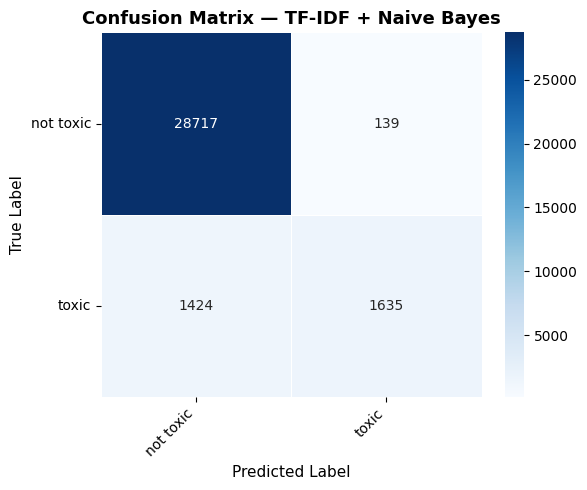

  [INFO] Confusion matrix saved → cm_TF-IDF_and_Naive_Bayes.png



In [ ]:
all_results = {}

name = "TF-IDF + Naive Bayes"
all_results[name] = evaluate_experiment(
    name, experiments[name], X_train, X_test, y_train, y_test, CLASSES
)

# CountVectorizer + Naive Bayes

  --- CountVectorizer + Naive Bayes ---
  Accuracy  : 0.9523
  Precision : 0.8973  (macro avg)
  Recall    : 0.8073  (macro avg)
  F1-Score  : 0.8450  (macro avg)

  Classification Report:

              precision    recall  f1-score   support

   not toxic       0.96      0.99      0.97     28856
       toxic       0.83      0.63      0.72      3059

    accuracy                           0.95     31915
   macro avg       0.90      0.81      0.85     31915
weighted avg       0.95      0.95      0.95     31915



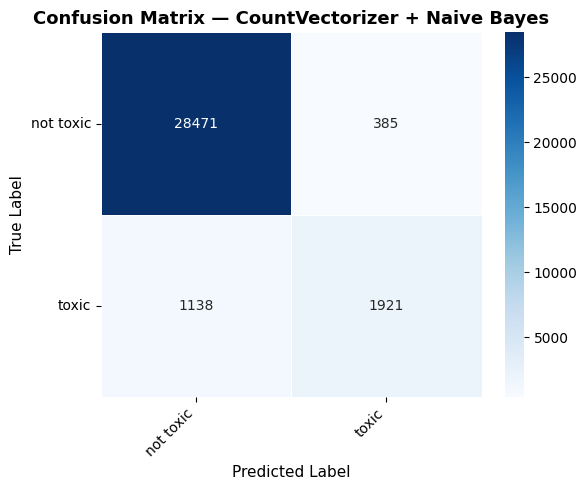

  [INFO] Confusion matrix saved → cm_CountVectorizer_and_Naive_Bayes.png



In [ ]:
name = "CountVectorizer + Naive Bayes"
all_results[name] = evaluate_experiment(
    name, experiments[name], X_train, X_test, y_train, y_test, CLASSES
)

#TF-IDF + Logistic Regression

  --- TF-IDF + Logistic Regression ---
  Accuracy  : 0.9580
  Precision : 0.9373  (macro avg)
  Recall    : 0.8074  (macro avg)
  F1-Score  : 0.8583  (macro avg)

  Classification Report:

              precision    recall  f1-score   support

   not toxic       0.96      0.99      0.98     28856
       toxic       0.91      0.62      0.74      3059

    accuracy                           0.96     31915
   macro avg       0.94      0.81      0.86     31915
weighted avg       0.96      0.96      0.95     31915



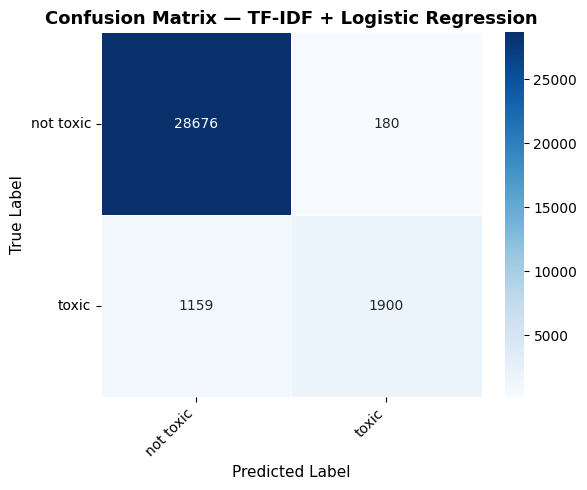

  [INFO] Confusion matrix saved → cm_TF-IDF_and_Logistic_Regression.png



In [ ]:
name = "TF-IDF + Logistic Regression"
all_results[name] = evaluate_experiment(
    name, experiments[name], X_train, X_test, y_train, y_test, CLASSES
)

# CountVectorizer + Logistic Regression

  --- CountVectorizer + Logistic Regression ---
  Accuracy  : 0.9562
  Precision : 0.9078  (macro avg)
  Recall    : 0.8228  (macro avg)
  F1-Score  : 0.8590  (macro avg)

  Classification Report:

              precision    recall  f1-score   support

   not toxic       0.96      0.99      0.98     28856
       toxic       0.85      0.66      0.74      3059

    accuracy                           0.96     31915
   macro avg       0.91      0.82      0.86     31915
weighted avg       0.95      0.96      0.95     31915



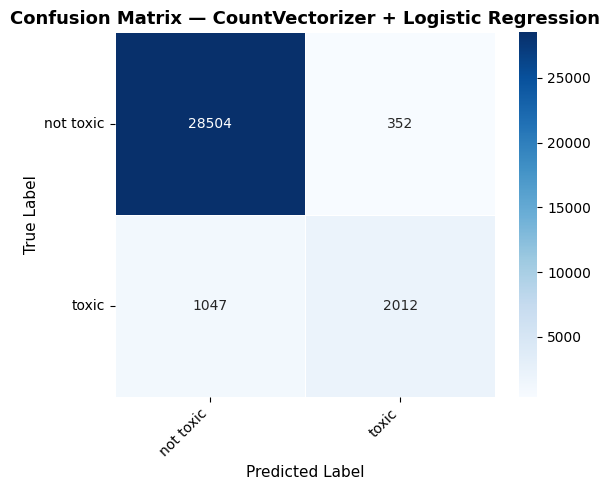

  [INFO] Confusion matrix saved → cm_CountVectorizer_and_Logistic_Regression.png



In [ ]:
name = "CountVectorizer + Logistic Regression"
all_results[name] = evaluate_experiment(
    name, experiments[name], X_train, X_test, y_train, y_test, CLASSES
)


#Final Comparison Summary



In [ ]:
rows = []
for name, m in all_results.items():
    rows.append({
        "Model Combination": name,
        "Accuracy" : round(m["accuracy"],  4),
        "Precision": round(m["precision"], 4),
        "Recall"   : round(m["recall"],    4),
        "F1-Score" : round(m["f1"],        4),
    })

summary_df = pd.DataFrame(rows).set_index("Model Combination")

summary_df.style.highlight_max(axis=0, color="#d4f1c4")

,Accuracy,Precision,Recall,F1-Score
Model Combination,,,,
TF-IDF + Naive Bayes,0.951000,0.937200,0.764800,0.825100
CountVectorizer + Naive Bayes,0.952300,0.897300,0.807300,0.845000
TF-IDF + Logistic Regression,0.958000,0.937300,0.807400,0.858300
CountVectorizer + Logistic Regression,0.956200,0.907800,0.822800,0.859000


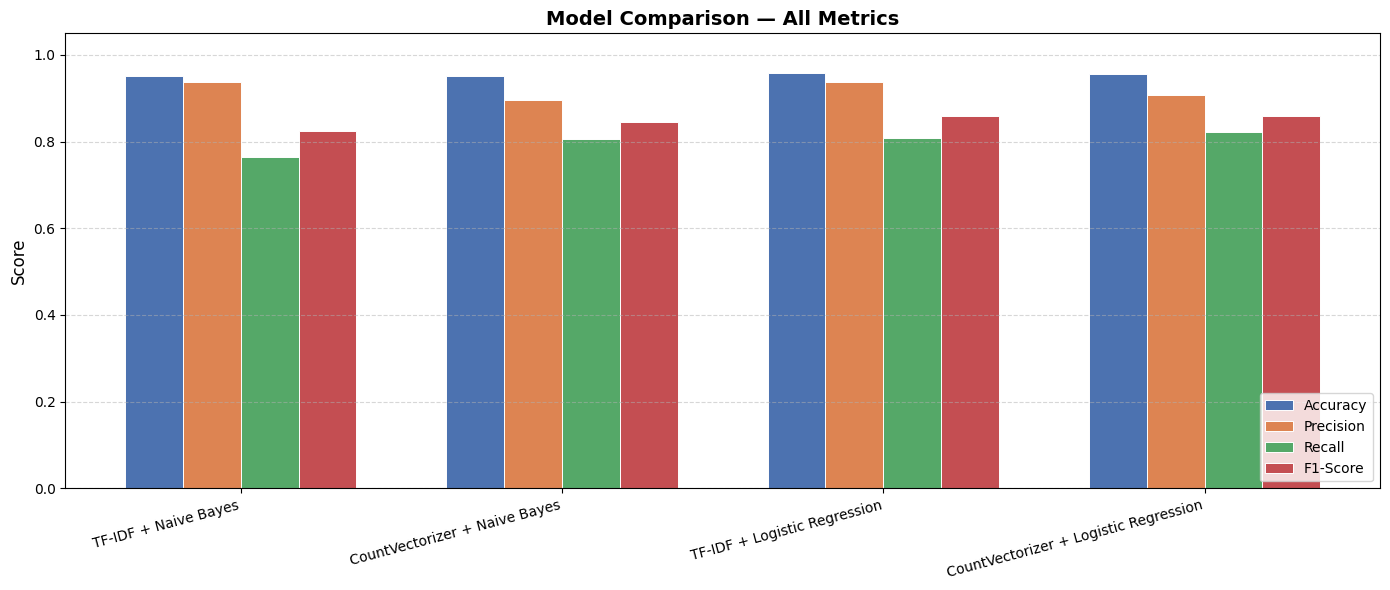

[INFO] Saved → model_comparison.png


In [ ]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
x      = np.arange(len(summary_df))
width  = 0.18
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, summary_df[metric], width,
           label=metric, color=colors[i], edgecolor="white", linewidth=0.7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(summary_df.index, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Comparison — All Metrics", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("[INFO] Saved → model_comparison.png")

In [ ]:
best_name = summary_df["F1-Score"].idxmax()
best_f1   = summary_df.loc[best_name, "F1-Score"]

tfidf_avg = summary_df[summary_df.index.str.contains("TF-IDF")]["F1-Score"].mean()
count_avg = summary_df[summary_df.index.str.contains("Count")]["F1-Score"].mean()
best_vec  = "TF-IDF" if tfidf_avg >= count_avg else "CountVectorizer"

nb_avg  = summary_df[summary_df.index.str.contains("Naive Bayes")]["F1-Score"].mean()
lr_avg  = summary_df[summary_df.index.str.contains("Logistic")]["F1-Score"].mean()
best_clf = "Logistic Regression" if lr_avg >= nb_avg else "Naive Bayes"

print("=" * 65)
print("  NARRATIVE SUMMARY")
print("=" * 65)
print(f""")
Best overall combination : {best_name}  (F1 = {best_f1:.4f})
Best vectorization method: {best_vec}   (avg F1 → TF-IDF: {tfidf_avg:.4f}, Count: {count_avg:.4f})
Best classifier          : {best_clf}   (avg F1 → LR: {lr_avg:.4f}, NB: {nb_avg:.4f})

""")

  NARRATIVE SUMMARY
)
Best overall combination : CountVectorizer + Logistic Regression  (F1 = 0.8590)
Best vectorization method: CountVectorizer   (avg F1 → TF-IDF: 0.8417, Count: 0.8520)
Best classifier          : Logistic Regression   (avg F1 → LR: 0.8586, NB: 0.8350)


